# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

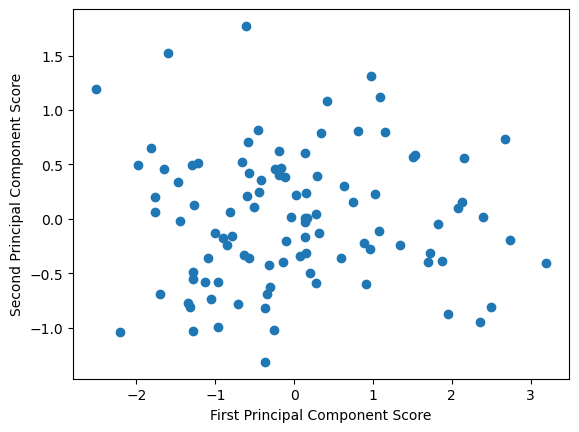

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

An advantage of a scatterplot would be that we can observe trends and outliers, if anything is linear or not.Because series 3 is applied the most noise and can portray a weaker relationship this definitely will contribute to the outliers and add more and more if it were to be graphed. It would be mostly just noise. The three outliers in the upper left have low scores on the first principal component and high scores on the second showing series 1 had lower average vs the series 2 variance which is higher.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [8]:
df = pd.read_csv("/Users/riverocel/Downloads/marketing_and_product_performance.csv")
df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


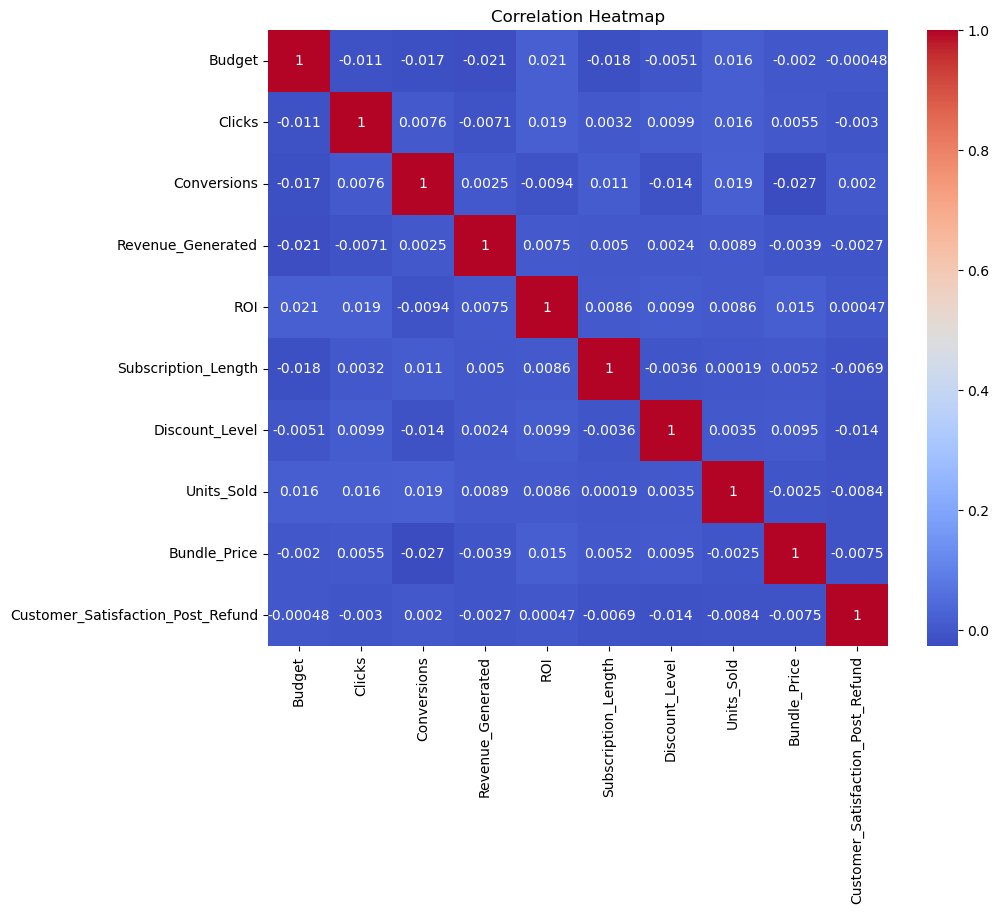

In [10]:
import seaborn as sns

numeric_cols = [
    'Budget','Clicks','Conversions','Revenue_Generated','ROI',
    'Subscription_Length','Discount_Level','Units_Sold',
    'Bundle_Price','Customer_Satisfaction_Post_Refund'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap is showing there is basically no correlation between any of the numerical variables and our target, which is understandable because this is a generated fake dataset. 

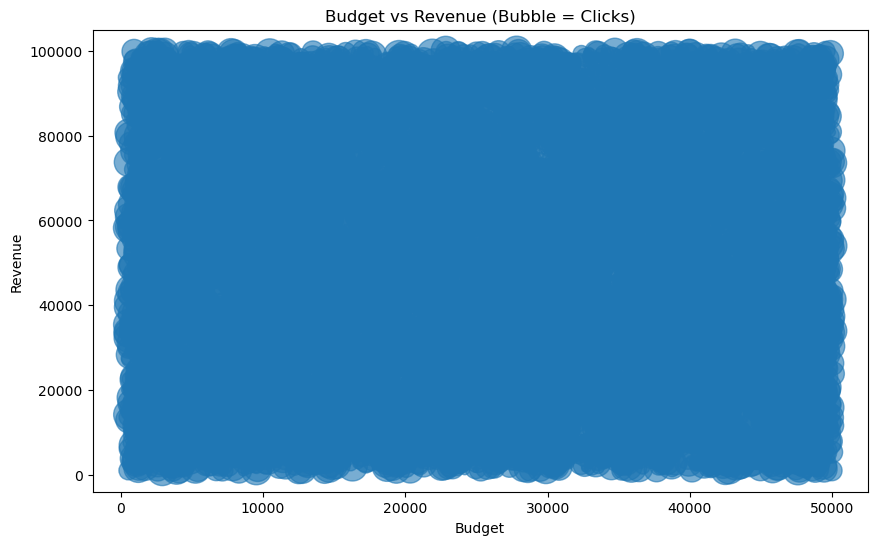

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Budget'],
    df['Revenue_Generated'],
    s=df['Clicks'] * 0.1,   # bubble size
    alpha=0.6
)

plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue (Bubble = Clicks)")
plt.show()

The bubbleplot as well shows nothing and no trends because the data is so bad that there are no relationships and just noise technically. So budget and revenue do not seem to have any correlation

In [13]:
from sklearn.preprocessing import StandardScaler

X = df[numeric_cols]
X_scaled = StandardScaler().fit_transform(X)
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.10532823 0.10424239 0.1029748  0.10065739 0.10036484 0.09984705
 0.09833435 0.09746791 0.09634027 0.09444278]


numerical columns all around 0.1-0.09 showing 10% variance, meaning all variables are somewhat the same of relevance. There is no dominant variable nor real structure between the variables and their position to the target. 

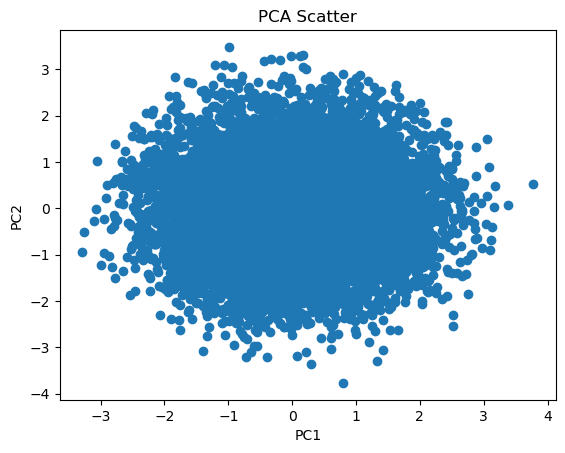

In [14]:
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter")
plt.show()

PC 1 VS PC 2 showcase some outliers like middle top portraying PC2 being more positive and higher than PC1 at the same value however there are also outliers around the middle left showing there are positive values for PC1 compared to PC2, so it really cannot make a final result to which one is better.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

features = ['Budget','Clicks','Conversions','Units_Sold','Discount_Level']
target = 'Revenue_Generated'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

-0.0011960270420434682


The r2 value is negative near 0, the model is worse than estimating mean from variables. 

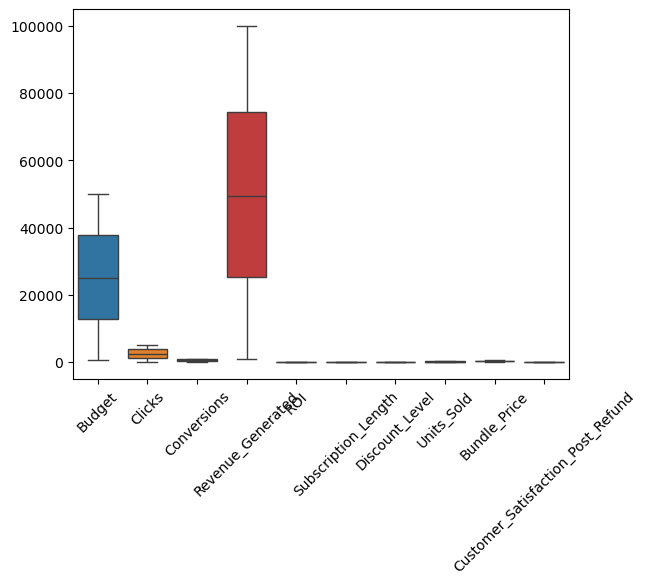

In [18]:
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

Revenue generation and budget seem to be the most varied variables with a wide range while the rest are really tight. However because the dataset doesn't necessarily showed any positive or negative relationships with our target, this doesn't really matter.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

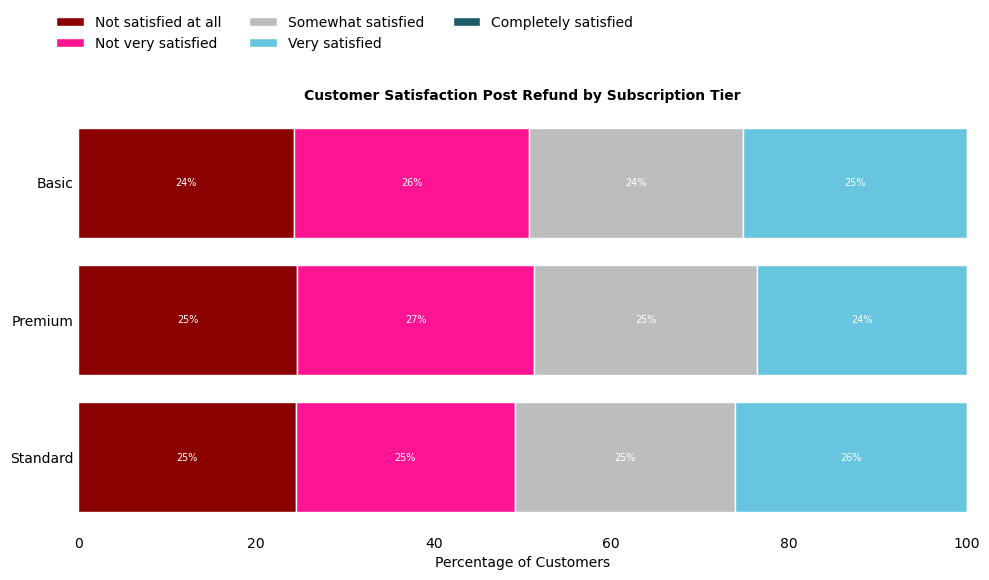

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy dataframe if needed
df_marketing = df.copy()

# Map numeric satisfaction scores to labels
satisfaction_map = {
    1: "Not satisfied at all",
    2: "Not very satisfied",
    3: "Somewhat satisfied",
    4: "Very satisfied",
    5: "Completely satisfied"
}

df_marketing["Satisfaction_Label"] = df_marketing["Customer_Satisfaction_Post_Refund"].map(satisfaction_map)

# Group by Subscription_Tier and satisfaction label
grouped = (
    df_marketing
    .groupby(["Subscription_Tier", "Satisfaction_Label"])
    .size()
    .unstack(fill_value=0)
)

# Ensure column order matches Likert order
ordered_cols = [
    "Not satisfied at all",
    "Not very satisfied",
    "Somewhat satisfied",
    "Very satisfied",
    "Completely satisfied"
]

grouped = grouped.reindex(columns=ordered_cols, fill_value=0)

# Convert counts to percentages
grouped_pct = grouped.div(grouped.sum(axis=1), axis=0) * 100

# Colors similar to the example
colors = [
    "#8B0000",  # Not satisfied at all
    "#FF1493",  # Not very satisfied
    "#BDBDBD",  # Somewhat satisfied
    "#67C5DF",  # Very satisfied
    "#1F5A6B"   # Completely satisfied
]

fig, ax = plt.subplots(figsize=(10, 6))

left = [0] * len(grouped_pct)

for i, col in enumerate(grouped_pct.columns):
    values = grouped_pct[col].values

    ax.barh(
        grouped_pct.index,
        values,
        left=left,
        color=colors[i],
        edgecolor="white",
        label=col
    )

    # Add percentage labels inside bars
    for j, val in enumerate(values):
        if val >= 5:
            ax.text(
                left[j] + val / 2,
                j,
                f"{val:.0f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=7
            )

    left = [left[k] + values[k] for k in range(len(values))]

ax.set_title("Customer Satisfaction Post Refund by Subscription Tier", fontsize=10, weight="bold")
ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of Customers")
ax.set_ylabel("")
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.3, 1.25),
    ncol=3,
    frameon=False
)

# Put first category at top
ax.invert_yaxis()

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()